In [1]:
import os
import nsdget
from PIL import Image
import matplotlib.pyplot as plt
plt.style.use("dark_background")

DATA_DIR = os.path.join("..", "data")

In [2]:
df = nsdget.df_stimuli_info(DATA_DIR)
df.head()

,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,...,subject5_rep2,subject6_rep0,subject6_rep1,subject6_rep2,subject7_rep0,subject7_rep1,subject7_rep2,subject8_rep0,subject8_rep1,subject8_rep2
0,532481,val2017,"[0.0, 0.0, 0.1671875, 0.1671875]",0.100000,0,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
1,245764,val2017,"[0.0, 0.0, 0.125, 0.125]",0.000000,1,False,False,False,0,0,...,0,0,0,0,13985,14176,28603,0,0,0
2,385029,val2017,"[0.0, 0.0, 0.125, 0.125]",0.000000,2,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
3,311303,val2017,"[0.0, 0.0, 0.16640625, 0.16640625]",0.125000,3,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
4,393226,val2017,"[0.0, 0.0, 0.125, 0.125]",0.133333,4,False,False,False,0,0,...,0,13720,22861,23023,0,0,0,0,0,0


In [3]:
df.columns

Index(['cocoId', 'cocoSplit', 'cropBox', 'loss', 'nsdId', 'flagged',
       'BOLD5000', 'shared1000', 'subject1', 'subject2', 'subject3',
       'subject4', 'subject5', 'subject6', 'subject7', 'subject8',
       'subject1_rep0', 'subject1_rep1', 'subject1_rep2', 'subject2_rep0',
       'subject2_rep1', 'subject2_rep2', 'subject3_rep0', 'subject3_rep1',
       'subject3_rep2', 'subject4_rep0', 'subject4_rep1', 'subject4_rep2',
       'subject5_rep0', 'subject5_rep1', 'subject5_rep2', 'subject6_rep0',
       'subject6_rep1', 'subject6_rep2', 'subject7_rep0', 'subject7_rep1',
       'subject7_rep2', 'subject8_rep0', 'subject8_rep1', 'subject8_rep2'],
      dtype='object')

In [4]:
shared1k = df[df["shared1000"]==True]
shared1k.head()

,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,...,subject5_rep2,subject6_rep0,subject6_rep1,subject6_rep2,subject7_rep0,subject7_rep1,subject7_rep2,subject8_rep0,subject8_rep1,subject8_rep2
2950,262145,train2017,"[0.0, 0.0, 0.16640625, 0.16640625]",0.09375,2950,False,True,True,1,1,...,27566,2616,9716,27566,2616,9716,27566,2616,9716,27566
2990,262239,train2017,"[0.0, 0.0, 0.1671875, 0.1671875]",0.10000,2990,False,True,True,1,1,...,27711,18458,18697,27711,18458,18697,27711,18458,18697,27711
3049,262414,train2017,"[0.0, 0.0, 0.125, 0.125]",0.00000,3049,False,True,True,1,1,...,6697,6299,6448,6697,6299,6448,6697,6299,6448,6697
3077,524646,train2017,"[0.0, 0.0, 0.1671875, 0.1671875]",0.00000,3077,False,True,True,1,1,...,4537,4289,4515,4537,4289,4515,4537,4289,4515,4537
3146,262690,train2017,"[0.0, 0.0, 0.16640625, 0.16640625]",0.00000,3146,False,True,True,1,1,...,26807,8087,8443,26807,8087,8443,26807,8087,8443,26807


In [5]:
shared1k["img"] = nsdget.df_download_stimuli_images(shared1k, DATA_DIR)

/var/folders/lr/70kn5pjn69bdqbrtq53m3nch0000gn/T/ipykernel_24710/287722206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared1k["img"] = nsdget.df_download_stimuli_images(shared1k, DATA_DIR)


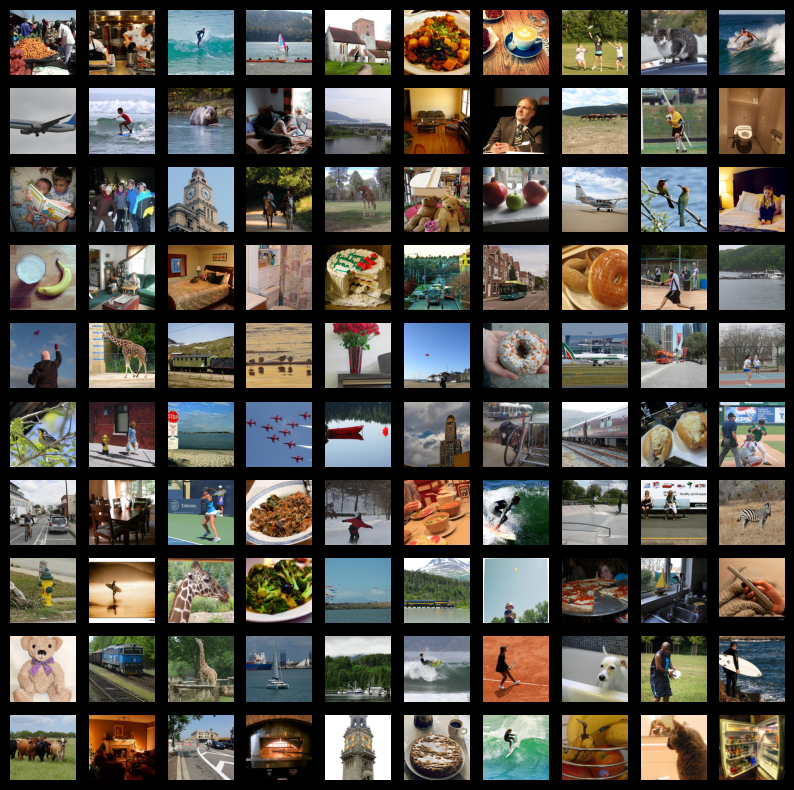

In [6]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
	row = shared1k.iloc[i]
	im = Image.open(row["img"])
	ax.imshow(im)
	ax.axis("off")

Open image as numpy format

(425, 425, 3)


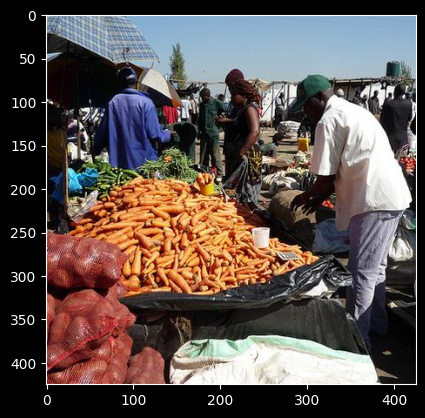

In [12]:
import numpy as np
arr = np.asarray(Image.open(shared1k.iloc[0]["img"]))
print(arr.shape)
plt.imshow(arr)

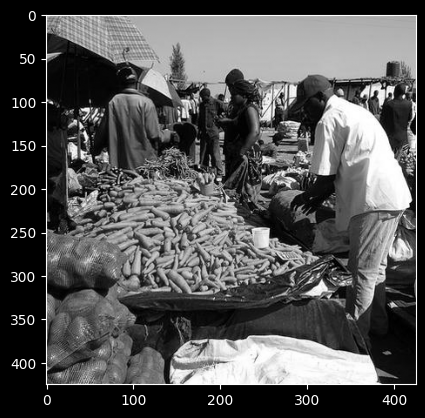

In [27]:
plt.imshow(arr.mean(axis=-1), cmap="grey")